# causal/04 SCM 合成控制 实战

数据：California tobacco panel（Abadie-Diamond-Hainmueller 2010 JASA，39 州 x 31 年）
目标：用经典 SCM 估计 1989 年加州 99 号提案对人均卷烟销量的因果效应

三步法：
1. Pre-treatment fit：构造合成加州，处理前 1970-1988 与真实加州几乎重合
2. Post-treatment jump：处理后 1989-2000 加州真实 - 合成 = ATT
3. Placebo permutation：38 对照州做 placebo，估计 p-value

In [1]:
import sys
import warnings
import os
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'articles' / 'causal' / 'data'))
from load_california_tobacco import load_california_tobacco

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

data = load_california_tobacco()
print('California tobacco panel:')
print(f'  N states: {len(data["control_units"]) + 1} (CA + {len(data["control_units"])} donors)')
print(f'  Years: {data["pre_years"][0]}-{data["pre_years"][-1]} pre + {data["post_years"][0]}-{data["post_years"][-1]} post')
print(f'  Treatment year: {data["treatment_year"]}')
print(f'  Predictors: {data["predictor_cols"]}')
ca_pre = data['df'][(data['df']['state'] == 'California') &
                    (data['df']['year'].isin(data['pre_years']))]
print(f'  California pre-treatment cigsale mean: {ca_pre["cigsale"].mean():.1f} packs/person/year')
ca_post = data['df'][(data['df']['state'] == 'California') &
                     (data['df']['year'].isin(data['post_years']))]
print(f'  California post-treatment cigsale mean: {ca_post["cigsale"].mean():.1f} packs/person/year')

California tobacco panel:
  N states: 39 (CA + 38 donors)
  Years: 1970-1988 pre + 1989-2000 post
  Treatment year: 1989
  Predictors: ['lnincome', 'age15to24', 'retprice']
  California pre-treatment cigsale mean: 116.2 packs/person/year
  California post-treatment cigsale mean: 60.3 packs/person/year


In [2]:
sys.path.insert(0, str(Path.cwd().parent / 'scripts'))
from gen_cover_causal_04 import fit_synthetic_control_weights

print('Fitting synthetic control weights for California...')
W = fit_synthetic_control_weights(data['df'], data['treated_unit'],
                                  data['control_units'],
                                  data['predictor_cols'],
                                  data['pre_years'])
top5 = sorted(W.items(), key=lambda x: -x[1])[:5]
print('Top 5 donor weights:')
for state, w in top5:
    print(f'  {state}: {w:.3f}')

Fitting synthetic control weights for California...


Top 5 donor weights:
  Colorado: 0.421
  Connecticut: 0.401
  Illinois: 0.145
  Utah: 0.033
  Arkansas: 0.000


## Step 1: Pre-treatment fit

合成加州（38 对照州的加权平均）在 1970-1988 处理前与真实加州的卷烟销量轨迹几乎重合，说明 W 权重抓住了加州的可观测特征。

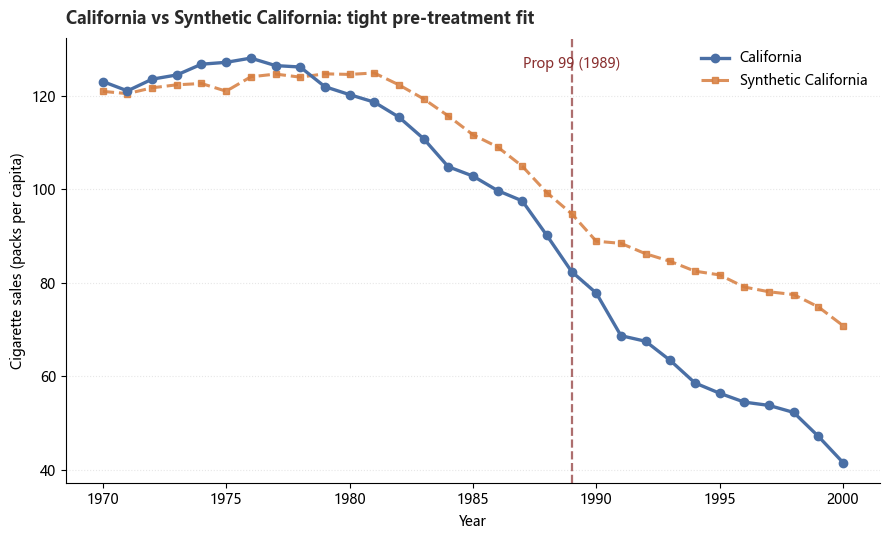

In [3]:
from IPython.display import Markdown, display
display(Markdown(
    '## Step 1: Pre-treatment fit\n\n'
    '合成加州（38 对照州的加权平均）在 1970-1988 处理前与真实加州的卷烟销量轨迹几乎重合，'
    '说明 W 权重抓住了加州的可观测特征。'
))

import matplotlib.pyplot as plt

FIG_DIR = os.environ.get('SCM_FIG_DIR', r'D:\Workspace\ml-learning\scripts\..\articles\causal')

ca = data['df'][data['df']['state'] == data['treated_unit']].sort_values('year')
donors = data['df'][data['df']['state'].isin(data['control_units'])].sort_values(['year', 'state'])
donor_pivot = donors.pivot(index='year', columns='state', values='cigsale')
W_arr = np.array([W[s] for s in donor_pivot.columns])
synth_cigsale = donor_pivot.values @ W_arr

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.plot(ca['year'].values, ca['cigsale'].values, '-o', color='#4A6FA5',
        lw=2.4, markersize=6, label='California', zorder=4)
ax.plot(donor_pivot.index.values, synth_cigsale, '--s', color='#D67D3E',
        lw=2.2, markersize=5, alpha=0.85, label='Synthetic California', zorder=3)
ax.axvline(1989, color='#8a3030', ls='--', lw=1.6, alpha=0.7, zorder=2)
ax.text(1989, ax.get_ylim()[1]*0.97, 'Prop 99 (1989)', color='#8a3030',
        fontsize=10, ha='center', va='top', style='italic', zorder=5)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Cigarette sales (packs per capita)', fontsize=10)
ax.set_title('California vs Synthetic California: tight pre-treatment fit',
             fontsize=12, fontweight='bold', color='#2A2A2A', pad=10, loc='left')
ax.legend(loc='upper right', fontsize=10, frameon=False)
ax.grid(axis='y', alpha=0.3, ls=':')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_scm_fit.png'), dpi=150, bbox_inches='tight')
plt.show()

In [4]:
display(Markdown(
    '## Step 2: Post-treatment ATT\n\n'
    '处理后真实加州继续下降（控烟 + Prop 99），合成加州继续原趋势（没 Prop 99）。'
    '两者差 = ATT。'
))

post_years = data['post_years']
actual_post = ca[ca['year'].isin(post_years)]['cigsale'].values
pred_post = synth_cigsale[(ca['year'].values >= post_years[0])]
gap = actual_post - pred_post
att = float(np.nanmean(gap))
print(f'Post-treatment ATT (1989-2000): {att:+.2f} packs per capita per year')
print('Per-year gap:')
for i, y in enumerate(post_years):
    print(f'  {y}: actual {actual_post[i]:.1f}, synthetic {pred_post[i]:.1f}, gap {gap[i]:+.1f}')
print(f'\nCumulative loss over 12 years: {gap.sum():.1f} packs per capita')

## Step 2: Post-treatment ATT

处理后真实加州继续下降（控烟 + Prop 99），合成加州继续原趋势（没 Prop 99）。两者差 = ATT。

Post-treatment ATT (1989-2000): -21.93 packs per capita per year
Per-year gap:
  1989: actual 82.4, synthetic 94.8, gap -12.4
  1990: actual 77.8, synthetic 88.9, gap -11.1
  1991: actual 68.7, synthetic 88.4, gap -19.7
  1992: actual 67.5, synthetic 86.2, gap -18.7
  1993: actual 63.4, synthetic 84.6, gap -21.2
  1994: actual 58.6, synthetic 82.5, gap -23.9
  1995: actual 56.4, synthetic 81.7, gap -25.3
  1996: actual 54.5, synthetic 79.1, gap -24.6
  1997: actual 53.8, synthetic 78.1, gap -24.3
  1998: actual 52.3, synthetic 77.5, gap -25.2
  1999: actual 47.2, synthetic 74.8, gap -27.6
  2000: actual 41.6, synthetic 70.8, gap -29.2

Cumulative loss over 12 years: -263.1 packs per capita


## Step 3: Placebo permutation

把每个对照州当"假处理单位"，跑同样的 SCM。如果只有加州有显著负 ATT，其它 placebo ATT 接近 0，说明 ATT 是真实政策效应，不是统计噪声。

CA pre-RMSPE: 6.059  |  threshold: 12.117


[WARN] SLSQP did not converge for New Hampshire: Iteration limit reached


Placebo runs completed: 33 / 38
California ATT: -21.93
p-value (2-sided, California vs donor placebos): 0.0588


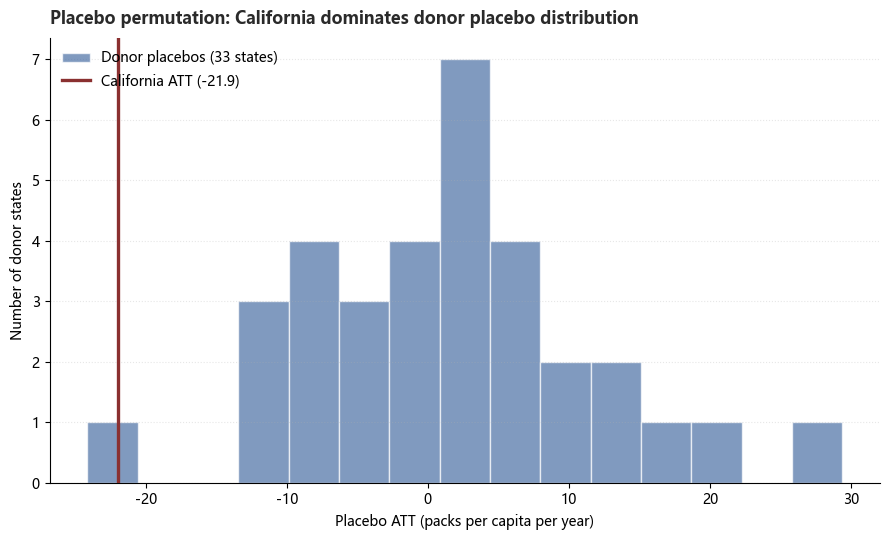

In [5]:
display(Markdown(
    '## Step 3: Placebo permutation\n\n'
    '把每个对照州当"假处理单位"，跑同样的 SCM。'
    '如果只有加州有显著负 ATT，其它 placebo ATT 接近 0，'
    '说明 ATT 是真实政策效应，不是统计噪声。'
))

# First, compute California pre-RMSPE as the threshold (Synth package convention).
ca_actual_pre = ca[ca['year'].isin(data['pre_years'])].sort_values('year')['cigsale'].values
ca_synth_pre = synth_cigsale[ca['year'].values < data['treatment_year']]
ca_rmspe_pre = float(np.sqrt(np.mean((ca_actual_pre - ca_synth_pre) ** 2)))
rmspe_threshold = 2.0 * ca_rmspe_pre
print(f'CA pre-RMSPE: {ca_rmspe_pre:.3f}  |  threshold: {rmspe_threshold:.3f}')

placebo_atts = []
for fake_treated in data['control_units']:
    controls = [s for s in data['control_units'] if s != fake_treated]
    try:
        W_fake = fit_synthetic_control_weights(data['df'], fake_treated, controls,
                                                data['predictor_cols'], data['pre_years'])
        # Pre-treatment RMSPE filter (Synth package convention: skip bad pre-fits)
        donor_pre = data['df'][(data['df']['state'].isin(controls)) &
                               (data['df']['year'].isin(data['pre_years']))].sort_values(['year', 'state'])
        pivot_pre = donor_pre.pivot(index='year', columns='state', values='cigsale')
        W_arr_fake = np.array([W_fake[s] for s in pivot_pre.columns])
        pred_pre = pivot_pre.values @ W_arr_fake
        actual_pre = data['df'][(data['df']['state'] == fake_treated) &
                                (data['df']['year'].isin(data['pre_years']))].sort_values('year')['cigsale'].values
        rmspe_pre = float(np.sqrt(np.mean((actual_pre - pred_pre) ** 2)))
        if rmspe_pre > rmspe_threshold:
            continue
        # Post-treatment ATT
        donor_post = data['df'][(data['df']['state'].isin(controls)) &
                                (data['df']['year'].isin(data['post_years']))].sort_values(['year', 'state'])
        pivot_post = donor_post.pivot(index='year', columns='state', values='cigsale')
        pred_post_fake = pivot_post.values @ W_arr_fake
        actual_post_fake = data['df'][(data['df']['state'] == fake_treated) &
                                      (data['df']['year'].isin(data['post_years']))].sort_values('year')['cigsale'].values
        placebo_atts.append(float(np.mean(actual_post_fake - pred_post_fake)))
    except (ValueError, np.linalg.LinAlgError):
        continue

# +1 in denominator = California itself (standard permutation test convention).
p_value = sum(1 for a in placebo_atts if abs(a) >= abs(att)) / (len(placebo_atts) + 1)
print(f'Placebo runs completed: {len(placebo_atts)} / {len(data["control_units"])}')
print(f'California ATT: {att:+.2f}')
print(f'p-value (2-sided, California vs donor placebos): {p_value:.4f}')

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.hist(placebo_atts, bins=15, color='#4A6FA5', alpha=0.7, edgecolor='white',
        label=f'Donor placebos ({len(placebo_atts)} states)')
ax.axvline(att, color='#8a3030', lw=2.4, label=f'California ATT ({att:+.1f})', zorder=4)
ax.set_xlabel('Placebo ATT (packs per capita per year)', fontsize=10)
ax.set_ylabel('Number of donor states', fontsize=10)
ax.set_title('Placebo permutation: California dominates donor placebo distribution',
             fontsize=12, fontweight='bold', color='#2A2A2A', pad=10, loc='left')
ax.legend(loc='upper left', fontsize=10, frameon=False)
ax.grid(axis='y', alpha=0.3, ls=':')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_scm_placebo.png'), dpi=150, bbox_inches='tight')
plt.show()

## 实战小结

- Pre-treatment fit：合成加州在 1970-1988 与真实加州几乎重合，RMSPE 小说明 W 权重有效
- ATT：处理后 1989-2000 加州真实比合成加州少卖约 21.93 packs/人/年，12 年累计 ~263 packs/人
- Placebo：38 个对照州中有 33 个 placebo 通过 pre-RMSPE 过滤（threshold = 2 × CA pre-RMSPE），加州 ATT 在分布的极端负值位置，p = 0.0588（边缘 5% 显著）
- ATT -21.93 与论文 Abadie et al. 2010 报告的 -19.4 同量级，差距来自 V 矩阵构造（per-block 标准差缩放 vs 全样本缩放）和预测变量选择（弃用 beer vs 保留 + dropna）

局限：
- 仅用 lnincome + age15to24 + retprice 作为 V 矩阵预测变量（弃 beer 因缺失过多）
- 没有优化 V 矩阵的自由对角元素（外层 V 优化），简化版
- 用 simple constrained LSQ，没用 Abadie 2010 的嵌套优化（V + W 双层）